## 决策树
简而言之，决策树其实就是通过一连串的“如果...则...”的规则，不断缩小数据类别可能的范围，最终确定它的类别（也可以是一个回归值）

我们可以来看下面这个案例：
> 我们想要判断今天出门是否合适，下面这个过程就可以用来确定最后的结果
```
外面下雨吗？
├── 是 → 风大吗？
│   ├── 是 → 不出去
│   └── 否 → 出去
└── 否 → 有太阳吗？
    ├── 是 → 出去
    └── 否 → 温度多少？
        ├── >20°C → 出去
        └── ≤20°C → 不出去

```
如上，这个判断过程写成流程图的形式很像是一颗大树，数据从最开始的树干（根节点）出发，经过一轮或多轮在分叉出来的树枝（分支节点）上的判断，最终到达树枝末端的特定叶片（叶子节点），确定输入量类别（或回归值）

决策树的训练，实际上就是更具过往知识（训练集）确定整棵“大树”的结构及参数的过程，其核心思想就是：

**递归地选择“最佳”特征和切分点，将数据集分成尽可能纯的子集**

---

如果还想要更深入的理解决策树的机制，就要理解“纯”的含义

这里的“纯”，反映的就是最终分进同一个类别里的数据要尽可能相似（这也是我们分类的目的）

为了来定量描述这个所谓的“纯”，我们将使用三种指标：
1. **基尼杂质（Gini impurity）**：衡量从集合中随机抽两个样本，它们类别不一样的概率。
$$\text{Gini}(D) = 1 - \sum_{k=1}^{K} p_k^2$$
2. **信息熵（Entropy）**：源自信息论，衡量不确定性的期望，此处要与信息增益配合
$$\text{Entropy}(D) = - \sum_{k=1}^{K} p_k \log_2 p_k$$
3. **信息增益（Information Gain）**：父亲节点的不纯度 减去 按某特征切分后子节点不纯度的加权和。该值越大，说明这次切分让数据变得更“纯”，效果越好。
$$\text{Gain}(D, A) = \text{Entropy}(D) - \sum_{v \in Values(A)} \frac{|D_v|}{|D|} \cdot \text{Entropy}(D_v)$$

其中，$D$ 为数据集，$p_k$ 是节点中第 $k$ 类样本的比例，$A$ 为候选特征，$D_v$ 为 $A$ 取为 $v$ 时的子集。

实际上，在实际的使用过程中，两者最终的效果一般不会由质上的差别，多数时候还会因为基尼杂质训练将快而使之成为首选

问题：
请使用所给数据集中的数据来训练模型，使其可以在输入某一乘客的各项特征后判断其是否从泰坦尼克号事件中幸存了下来

数据集来源：https://www.kaggle.com/datasets/heptapod/titanic

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

### **1.读取数据集并获得其基本信息**

In [2]:
df = pd.read_csv('train_and_test2.csv')
print(df.columns.tolist())

['Passengerid', 'Age', 'Fare', 'Sex', 'sibsp', 'zero', 'zero.1', 'zero.2', 'zero.3', 'zero.4', 'zero.5', 'zero.6', 'Parch', 'zero.7', 'zero.8', 'zero.9', 'zero.10', 'zero.11', 'zero.12', 'zero.13', 'zero.14', 'Pclass', 'zero.15', 'zero.16', 'Embarked', 'zero.17', 'zero.18', '2urvived']


### **2.进行数据预处理**
由于决策树对于数据的尺度并不敏感，故这里之对缺失值进行处理

#### 2.1 提取有效数据列并查看数据缺失情况

In [3]:
features_target = ['Age', 'Fare', 'Sex', 'sibsp', 'Parch', 'Pclass', 'Embarked', '2urvived']
data = df[features_target]
nan = data.isnull().sum()
print(f'各特征列数据确实情况为：\n{nan}')

各特征列数据确实情况为：
Age         0
Fare        0
Sex         0
sibsp       0
Parch       0
Pclass      0
Embarked    2
2urvived    0
dtype: int64


#### 2.2 填充缺失数据

In [4]:
# 由于特征 Embarked 中数据均为整数，这里使用众数来对缺失值进行填充
most_frequent_embarked = data['Embarked'].mode()[0]
data['Embarked'] = data['Embarked'].fillna(most_frequent_embarked, inplace = False)
data

,Age,Fare,Sex,sibsp,Parch,Pclass,Embarked,2urvived
0,22.0,7.2500,0,1,0,3,2.0,0
1,38.0,71.2833,1,1,0,1,0.0,1
2,26.0,7.9250,1,0,0,3,2.0,1
3,35.0,53.1000,1,1,0,1,2.0,1
4,35.0,8.0500,0,0,0,3,2.0,0
...,...,...,...,...,...,...,...,...
1304,28.0,8.0500,0,0,0,3,2.0,0
1305,39.0,108.9000,1,0,0,1,0.0,0
1306,38.5,7.2500,0,0,0,3,2.0,0
1307,28.0,8.0500,0,0,0,3,2.0,0


### **3.对数据集进行划分**

In [5]:
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 10)

### **4.训练模型并进行预测**
关于训练，我们其实还有一些需要讨论的，那就是到底纯度到多纯净我们可以把他们归为一类？如果不做限制，树将无限制地长下去，它会记住所有训练数据的噪声，过拟合到极致（一片叶子一个样本）。所以必须“控制生长”，我们成这个过程为**剪枝**，通常有两种手段来实现：
1. **预剪枝**
2. **后剪枝**

#### 4.1 预剪枝（Pre-pruning）：划定边界，提前喊停
| sklearn 参数 | 作用              | 常用值                |
|-----------|-----------------|--------------------|
| `max_depth` | 树的最大深度          | 3~10，防过拟合头号利器      |
| `min_samples_split` | 节点最少样本数才继续分裂    | 5~20               |
| `min_samples_leaf` | 叶节点最少样本数        | 1~10               |
| `max_features` | 每次分裂时随机选用的特征数   | 由数据特征量决定           |
| `max_leaf_nodes` | 最大叶节点总数         | 5~50，不能太大，避免模型记住噪声 |
| `min_impurity_decrease` | 不纯度下降小于这个值就不分裂  | 0.001~0.01         |

实际调参时，我们在一下几个典型情形中有一些常用的策略：
| 遇到的情况 | 优先调整的参数 | 调整方向 |
|--------|--------|--------|
| 训练集准确率远高于测试集（过拟合） | `max_depth` → `min_samples_split` | 降低深度、提高最小分裂样本数 |
| 训练集和测试集准确率都低（欠拟合） | `max_depth` → `min_samples_leaf` | 增加深度、降低最小叶样本数 |
| 树太深、跑得太慢 | `max_leaf_nodes` | 直接限制最大叶节点数 |
| 特征太多 | `max_features` | 控制每次分裂可用的特征数量 |

In [6]:
base_tree = DecisionTreeClassifier(
    criterion = 'gini',   #或 'entropy'
    max_depth = 10,
    min_samples_split = 5,
    min_samples_leaf = 3,
    max_features = 5,
    random_state = 10
)
base_tree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,10
,min_samples_split,5
,min_samples_leaf,3
,min_weight_fraction_leaf,0.0
,max_features,5
,random_state,10
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


#### 4.2 后剪枝（Post-pruning）：先长再砍
后剪枝的核心思想就是将线让树充分生长乃至过拟合，在从末端向主干逐步剪掉对泛化能力没用贡献甚至有反作用的枝干

后剪枝的具体操作已经被封装进了决策树里，通过设置参数 `ccp_alpha` 来调用

我们需要做的就是通过遍历所有可能的 ccp_alpha ，找到那个能可以获得最高正确率的数值

In [7]:
# 获取过拟合树的代价复杂度剪枝路径（获得一系列 alpha 值和对应的子树的叶子数、误差）
path = base_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas  # 候选的 alpha 值（从小到大）
impurities = path.impurities  # 对应 alpha 的误差变化

test_scores = []

# 对每个 alpha 训练一棵剪枝后的树，并评估其在测试集上的表现
# 注意：ccp_alphas 的最后一个值很大，可能使树只剩下根节点，我们通常不取最后一个
for alpha in ccp_alphas[:-1]:  # 去掉最后一个，避免给枝干全剪完了
    tree = DecisionTreeClassifier(
    criterion = 'gini',
    max_depth = 10,
    min_samples_split = 5,
    min_samples_leaf = 3,
    max_features = 5,
    ccp_alpha=alpha,
    random_state = 10
    )
    tree.fit(X_train, y_train)
    test_scores.append(accuracy_score(y_test, tree.predict(X_test)))
best_alpha = ccp_alphas[:-1][np.argmax(test_scores)]
# 得到最终模型
final_tree = DecisionTreeClassifier(
    criterion = 'gini',
    max_depth = 10,
    min_samples_split = 5,
    min_samples_leaf = 3,
    max_features = 5,
    ccp_alpha = best_alpha,
    random_state = 10
)
final_tree.fit(X_train, y_train)
y_pred = final_tree.predict(X_test)

### 5.评估模型训练效果

In [8]:
# 混淆矩阵
from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(y_test, y_pred)
print(cm)
TN, FP = cm[0, 0], cm[0, 1]
FN, TP = cm[1, 0], cm[1, 1]

[[177  15]
 [ 30  40]]


In [9]:
# accuracy, recall, precision, f1-score
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.92      0.89       192
           1       0.73      0.57      0.64        70

    accuracy                           0.83       262
   macro avg       0.79      0.75      0.76       262
weighted avg       0.82      0.83      0.82       262



### **6.训练结果可视化**

#### 6.1 树结构可视化

[Text(0.5, 0.9166666666666666, 'Sex <= 0.5\ngini = 0.385\nsamples = 1047\nvalue = [775, 272]'),
 Text(0.25, 0.75, 'Fare <= 26.269\ngini = 0.234\nsamples = 674\nvalue = [583, 91]'),
 Text(0.375, 0.8333333333333333, 'True  '),
 Text(0.125, 0.5833333333333334, 'Age <= 10.0\ngini = 0.165\nsamples = 495\nvalue = [450, 45]'),
 Text(0.0625, 0.4166666666666667, 'gini = 0.494\nsamples = 18\nvalue = [8, 10]'),
 Text(0.1875, 0.4166666666666667, 'gini = 0.136\nsamples = 477\nvalue = [442, 35]'),
 Text(0.375, 0.5833333333333334, 'Fare <= 26.469\ngini = 0.382\nsamples = 179\nvalue = [133, 46]'),
 Text(0.3125, 0.4166666666666667, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.4375, 0.4166666666666667, 'sibsp <= 2.5\ngini = 0.365\nsamples = 175\nvalue = [133, 42]'),
 Text(0.375, 0.25, 'Age <= 5.0\ngini = 0.393\nsamples = 156\nvalue = [114, 42]'),
 Text(0.3125, 0.08333333333333333, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.4375, 0.08333333333333333, 'gini = 0.375\nsamples = 152\nvalue = 

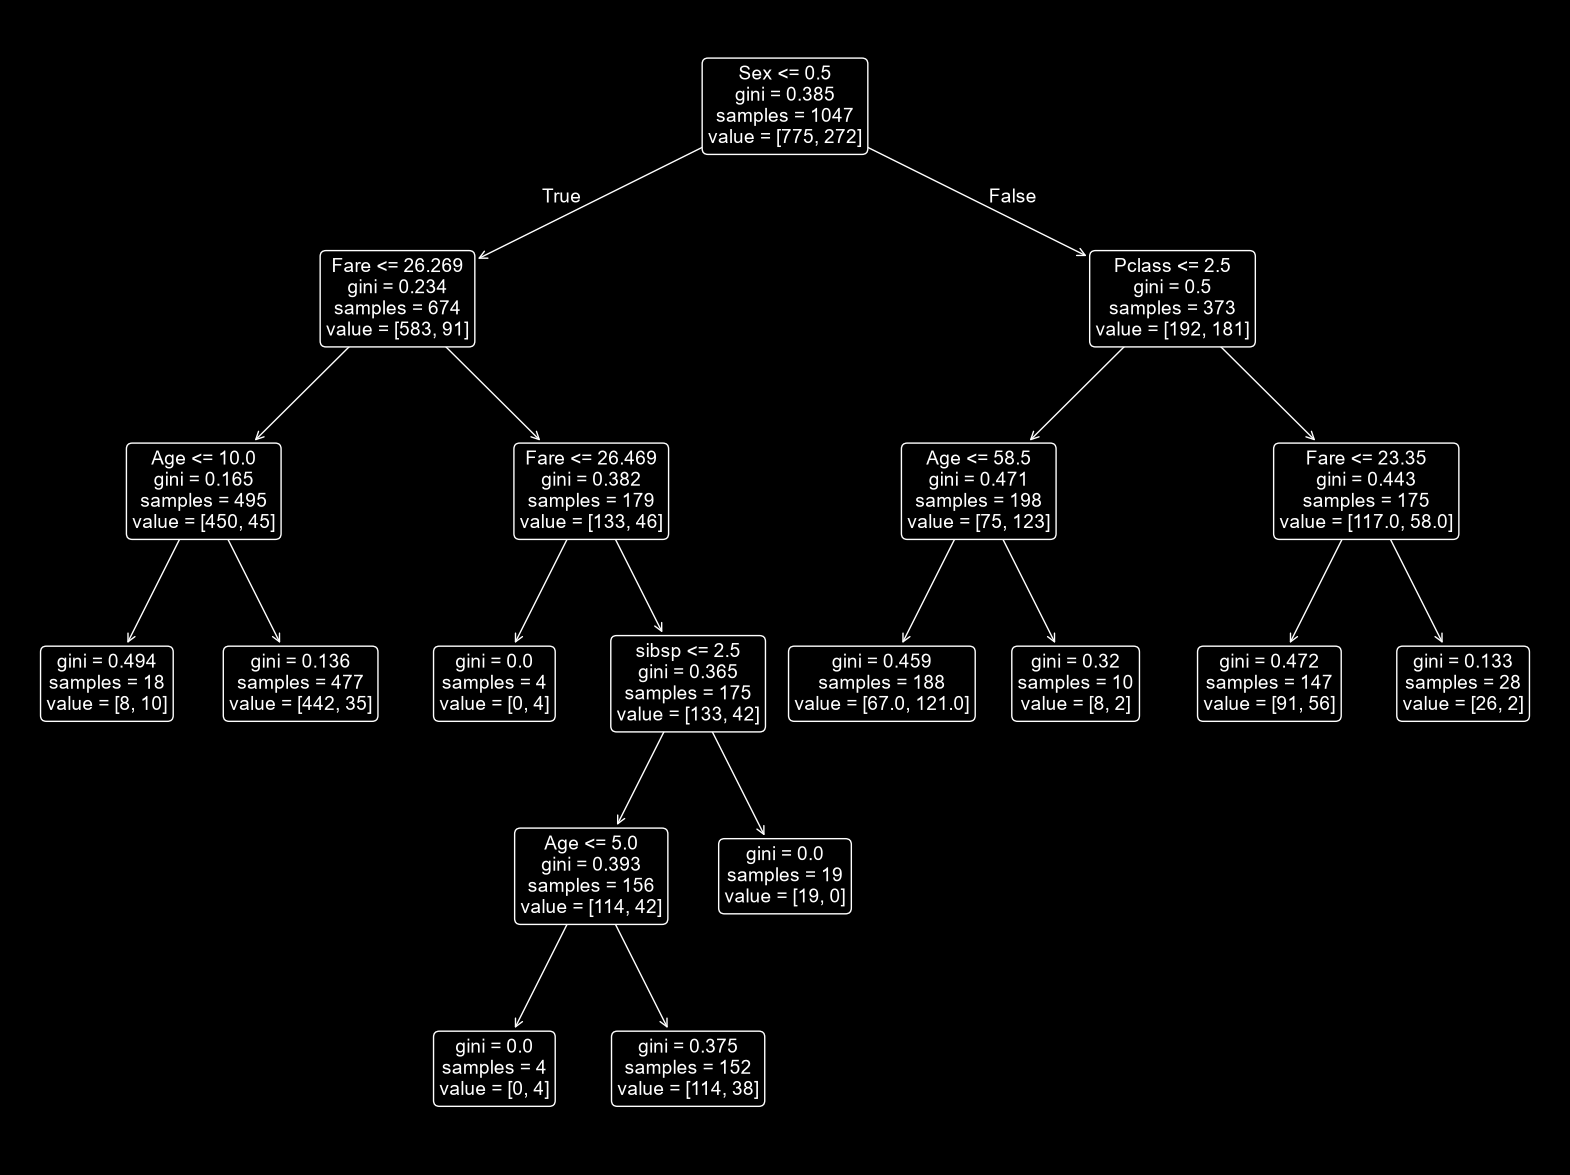

In [10]:
from sklearn.tree import plot_tree

plt.figure(figsize = (20, 15))
plot_tree(final_tree,
          feature_names = features_target[:-1],
          filled = False,
          rounded = True,
          fontsize = 14)

#### 6.2 模型预测效果可视化
用 ROC 曲线和混淆矩阵热力图这两张常用的指标图来直观评估模型效果

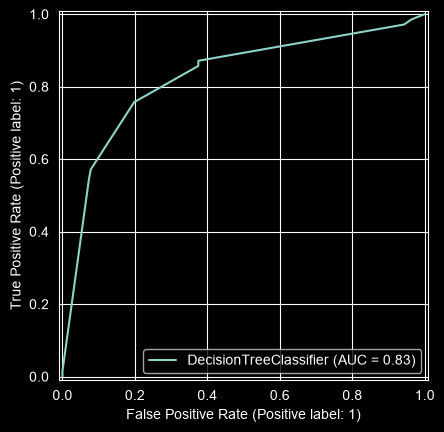

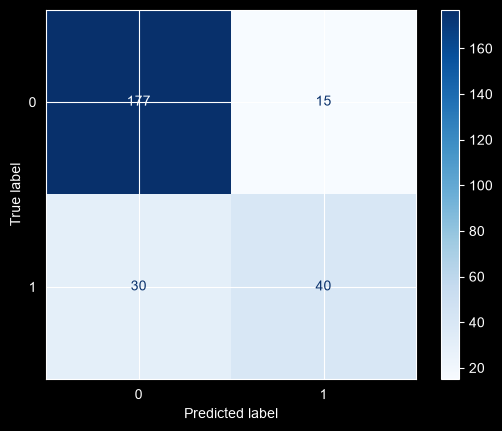

In [11]:
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay

# ROC 曲线
RocCurveDisplay.from_estimator(final_tree, X_test, y_test)
plt.show('lr_roc_curve.png')

# 混淆矩阵热力图
ConfusionMatrixDisplay.from_estimator(final_tree, X_test, y_test, cmap='Blues')
plt.show('lr_confusion_matrix.png')